# Geographically Weighted Regression (GWR) and MGWR
## Modeling spatial heterogeneity on San Diego census tracts

**Companion to deck `06-modeling-heterogeneity` (slides *Worked example — GWR on San Diego tracts* → *MGWR result — scales separate*).**

This notebook shows, step by step, how to:
1. Load the **San Diego census tracts** (`sandiego_tracts.gpkg`) and confirm a **metric CRS** (EPSG:3857) before mapping `median_house_value`.
2. **Standardise** the outcome and predictors (`median_hh_income`, `pct_rented`) and fit a **global OLS** baseline with `spreg.OLS` — the $R^2$ that GWR must beat.
3. Derive the **$(u, v)$ coordinates** from tract **centroids** in the projected CRS.
4. Select the **adaptive bisquare bandwidth** by **AICc** with `Sel_BW(...).search()`, then fit **GWR** and map the **local $R^2$**.
5. Read the **income coefficient surface** from `gwr.params` alongside a **multiple-testing-corrected significance mask** (`filter_tvals()`).
6. Run the **diagnostics**: a Monte-Carlo **spatial-stationarity test** (`spatial_variability()`) and **local multicollinearity** checks (`local_collinearity()` — VIF, condition number).
7. Fit **MGWR** with a **bandwidth per predictor** (`Sel_BW(..., multi=True)`), compare **AICc** against GWR, and confirm the scale separation with `get_bws_intervals()`.
8. Map the two **MGWR coefficient surfaces** side by side — patchy (local) income versus near-flat (global) `pct_rented` — and close on **when to use GWR vs MGWR**.

> Dataset: `data/sandiego/sandiego_tracts.gpkg` — 628 San Diego census tracts (ACS), in EPSG:3857 (metres), with `median_house_value`, `median_hh_income`, `pct_rented`.
> Source: Rey, Arribas-Bel & Wolf, *Geographic Data Science with Python* (https://geographicdata.science/book/); see also https://gdsl-ul.github.io/san/09-gwr.html


**Where this sits.** This is the companion notebook to deck `06-modeling-heterogeneity` (slides *Worked example — GWR on San Diego tracts* → *MGWR result — scales separate*). A **global** regression forces one slope per predictor everywhere; **GWR** replaces each global coefficient with a *surface* of local coefficients, and **MGWR** lets every predictor vary at its **own** spatial scale.

**Data.** San Diego census tracts — the same case used in Rey, Arribas-Bel & Wolf, *Geographic Data Science with Python* (https://geographicdata.science/book/) and the GDSL-UL *Spatial Analysis and Modelling* course (https://gdsl-ul.github.io/san/09-gwr.html). Shipped in `data/sandiego/`.

**Method grounding.** GWR/MGWR estimator and the `mgwr` API follow Oshan, Li, Kang, Wolf & Fotheringham (2019), *mgwr: A Python implementation of multiscale geographically weighted regression*, ISPRS IJGI 8(6):269 — the reference implementation we use throughout.

## Setup

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR, MGWR
from spreg import OLS

import warnings
warnings.filterwarnings("ignore")   # quiet harmless numpy2/BLAS notices
%matplotlib inline
plt.rcParams["figure.dpi"] = 90

## The data — San Diego census tracts

628 census tracts, already in a projected CRS (**EPSG:3857**, metres), so we can use Euclidean distances directly. Our outcome is `median_house_value`; the two predictors are `median_hh_income` and `pct_rented`.

In [2]:
gdf = gpd.read_file("data/sandiego/sandiego_tracts.gpkg")
print("CRS:", gdf.crs.to_string(), "| tracts:", len(gdf))
gdf[["median_house_value", "median_hh_income", "pct_rented"]].describe().round(1)

CRS: EPSG:3857 | tracts: 628


,median_house_value,median_hh_income,pct_rented
count,628.0,628.0,628.0
mean,515570.9,75402.8,0.4
std,267718.5,30463.0,0.2
min,17900.0,22614.0,0.0
25%,359200.0,52725.5,0.2
50%,454450.0,70189.5,0.4
75%,597400.0,92343.8,0.6
max,2000001.0,191642.0,1.0


### Map the outcome first
Before fitting, map the raw outcome: visible regional gradients and clusters are exactly the **spatial heterogeneity** GWR is meant to localise into varying coefficients.

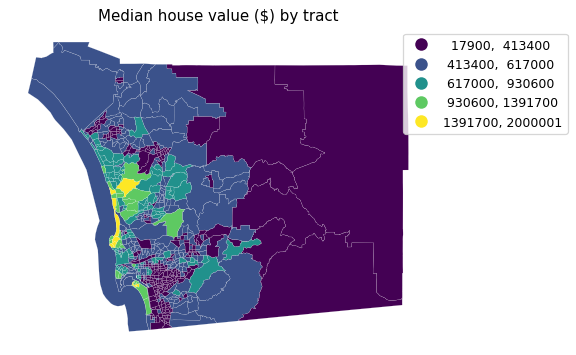

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
gdf.plot(column="median_house_value", cmap="viridis",
         scheme="FisherJenks", k=5, legend=True,
         legend_kwds={"bbox_to_anchor": (1.35, 1.0), "fmt": "{:.0f}"},
         linewidth=0.1, edgecolor="white", ax=ax)
ax.set_title("Median house value ($) by tract")
ax.axis("off")
plt.show()

House values rise sharply toward the **coast and central** tracts and fall inland — a smooth regional gradient a single global slope cannot capture. This is the pattern GWR will turn into a map of local coefficients.

## Select variables `y`, `X` (standardised)

We model census-tract `median_house_value` from `median_hh_income` and `pct_rented`. Following the deck, we **standardise** the outcome and both predictors (mean 0, sd 1) — this puts coefficients on a comparable scale and is required before the MGWR bandwidth search. `y` is a column vector; `X` has **no** intercept column — `mgwr` adds it for us.

In [4]:
z = lambda a: (a - a.mean()) / a.std()                 # standardise
y = z(gdf["median_house_value"].values).reshape(-1, 1) # shape (n, 1)
X = np.column_stack([z(gdf["median_hh_income"].values), # shape (n, k)
                     z(gdf["pct_rented"].values)])       # NO intercept
y.shape, X.shape

((628, 1), (628, 2))

### A global baseline
Fit ordinary least squares on the same two predictors — one slope each, valid *everywhere*. Its $R^2$ is the number GWR must beat.

In [5]:
ols = OLS(y, X, name_x=["income", "pct_rented"], name_y="house_value")
print("Global OLS R2 =", round(ols.r2, 3))

Global OLS R2 = 0.48


Global OLS explains **R² = 0.48** of the variation. Hold onto that number: if relationships really were constant across space, GWR could not do much better.

## Define coordinates $(u, v)$

GWR needs a location for each observation. For polygons we use the **centroid** of each tract, taken in the projected CRS.

In [6]:
c = gdf.geometry.centroid          # already projected (EPSG:3857)
coords = list(zip(c.x, c.y))       # [(x, y), ...]
coords[:3]

[(-13067416.44854367, 3921320.9998108987),
 (-13064581.67546763, 3924997.1606528806),
 (-13055960.574775163, 3905668.2910611457)]

## Estimate the GWR model

### Select the bandwidth
GWR fits, at each location $s_0$, a weighted least-squares regression that down-weights distant tracts through a **kernel**. The **bandwidth** sets how many neighbours each local fit sees — the single most consequential choice. With an **adaptive bisquare** kernel the bandwidth is a *count of nearest tracts*; `Sel_BW(...).search()` picks it by minimising **AICc** (its default).

In [7]:
gwr_selector = Sel_BW(coords, y, X)   # adaptive bisquare, AICc
gwr_bw = gwr_selector.search()
print("GWR bandwidth =", gwr_bw)      # nearest tracts per local fit

GWR bandwidth = 53.0


The search returns **bw = 53**: each tract's local regression borrows its **53 nearest neighbours**. Smaller would chase noise (high variance); larger would smooth back toward the global model (high bias).

### Fit and read the fit

In [8]:
gwr = GWR(coords, y, X, gwr_bw).fit()
print("Global R2 =", round(gwr.R2, 3))
print("AIC       =", round(gwr.aic, 1))
print("AICc      =", round(gwr.aicc, 1))

Global R2 = 0.766
AIC       = 1052.9
AICc      = 1084.6


One global regression has become a *local* fit everywhere. Global **R² rises to 0.77** — far above the OLS 0.48 on the same two predictors — and **AICc = 1084.6** is the baseline the MGWR step will try to beat.

**Lesson —** GWR trades one global coefficient for a *surface* of local ones, capturing spatial heterogeneity a single OLS number cannot show.

### Where does the model fit well? (local $R^2$)

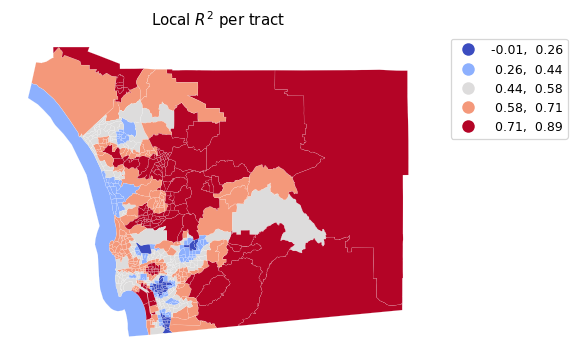

In [9]:
gdf["gwr_R2"] = gwr.localR2
fig, ax = plt.subplots(figsize=(6, 6))
gdf.plot(column="gwr_R2", cmap="coolwarm", scheme="FisherJenks", k=5,
         legend=True, legend_kwds={"bbox_to_anchor": (1.35, 1.0)},
         linewidth=0.1, edgecolor="white", ax=ax)
ax.set_title("Local $R^2$ per tract")
ax.axis("off")
plt.show()

Local $R^2$ ranges from near 0 to ~0.89: the two predictors explain house value far better in some parts of the county than others — itself a symptom of the heterogeneity we are modelling.

## The income coefficient surface

`mgwr` returns one coefficient row per location, so `params[:, k]` is a map-ready **surface**. Columns are `[intercept, income, pct_rented]` (the intercept is the column `mgwr` added). This is the payoff of GWR: a **map of the slope**, not a single number — *how strongly does income move house value* here.

In [10]:
gdf["b_intercept"] = gwr.params[:, 0]
gdf["b_income"]    = gwr.params[:, 1]
gdf["b_rented"]    = gwr.params[:, 2]

bi = gdf["b_income"]
print("income beta ranges %.2f .. %.2f" % (bi.min(), bi.max()))

income beta ranges -0.13 .. 2.19


The local income slope ranges from **−0.13 to 2.19** — near zero in some tracts, strongly positive in others. A global model would have reported a single average (~0.6) and hidden all of this.

### Significance mask (multiple-testing corrected)
With $n$ tracts $\times\ p$ predictors we run thousands of $t$-tests, so naive significance inflates false positives. `filter_tvals()` applies a multiple-testing correction and zeroes out the coefficients that do not survive it; read the coefficient map **only** where it does.

In [11]:
sig_raw = gwr.filter_tvals(alpha=0.05)[:, 1] != 0   # uncorrected
sig     = gwr.filter_tvals()[:, 1] != 0             # corrected
gdf["sig_income"] = sig
print("income significant (uncorrected): %d / %d" % (sig_raw.sum(), len(gdf)))
print("income significant (corrected):   %d / %d" % (sig.sum(), len(gdf)))

income significant (uncorrected): 434 / 628
income significant (corrected):   258 / 628


Uncorrected, the income effect passes at $\alpha=0.05$ in **434 / 628** tracts; after the multiple-testing correction it holds in **258 / 628**. The correction is not a technicality — it removes ~180 tracts we might otherwise over-interpret.

### Read the surface next to its mask
Always show the coefficient surface beside its significance mask — coefficients in non-significant tracts should not be over-interpreted.

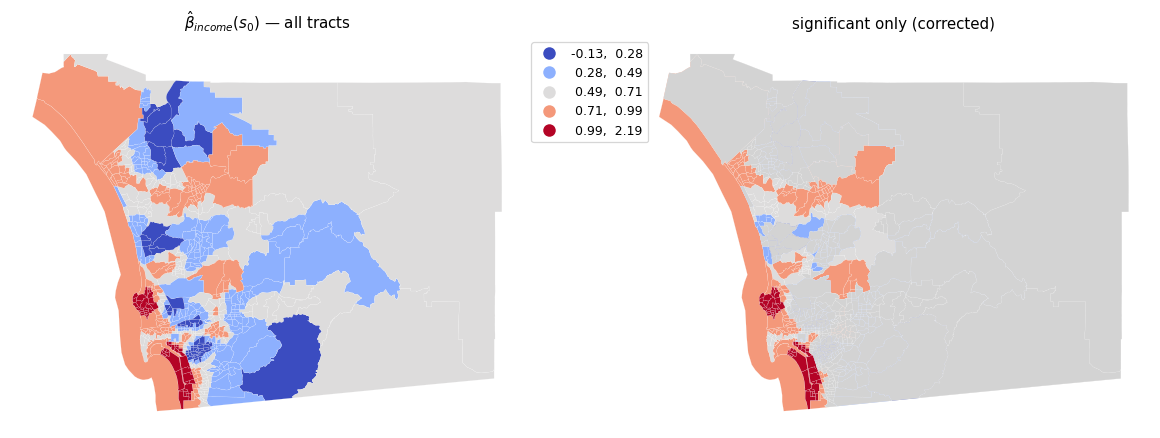

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

gdf.plot(column="b_income", cmap="coolwarm", scheme="FisherJenks", k=5,
         legend=True, legend_kwds={"bbox_to_anchor": (1.25, 1.0)},
         linewidth=0.1, edgecolor="white", ax=axes[0])
axes[0].set_title(r"$\hat{\beta}_{income}(s_0)$ — all tracts")

gdf.plot(column="b_income", cmap="coolwarm", scheme="FisherJenks", k=5,
         legend=False, linewidth=0.1, edgecolor="white", ax=axes[1])
gdf[~sig].plot(color="lightgrey", linewidth=0.1, edgecolor="white",
               ax=axes[1])
axes[1].set_title(r"significant only (corrected)")

for a in axes:
    a.axis("off")
plt.tight_layout()
plt.show()

**Left**: cooler = weaker, warm/red = a much stronger local income–value link. **Right**: only tracts that survive `filter_tvals()`; the income effect is strongest across the central/coastal tracts and unreliable elsewhere.

**Lesson —** a GWR coefficient map is trustworthy only where it is significant — always show the slope surface and its mask together.

## Diagnostics

### Is the variation real? (spatial-stationarity test)
A Monte-Carlo test compares each coefficient's *observed* spatial variance against the variance under randomly permuted locations. A small $p$ rejects $H_0: \beta_k(s) = \text{const}$ — the coefficient genuinely varies in space.

In [13]:
p_stationarity = gwr.spatial_variability(gwr_selector, 100)
pd.Series(p_stationarity, index=["intercept", "income", "pct_rented"],
          name="p_value").to_frame()

Testing:   0%|          | 0/100 [00:00<?, ?it/s]

,p_value
intercept,0.0
income,0.0
pct_rented,0.0


Both predictors have $p < 0.05$: their local estimates vary **more than chance** would produce, confirming that a global slope would be misleading.

### Local multicollinearity (VIF, condition number)
Overlapping kernels can make local predictors collinear and destabilise $\hat{\beta}(s_0)$. Rules of thumb: **VIF > 10** or **condition number (CN) > 30** flag trouble.

In [14]:
LCC, VIF, CN, VDP = gwr.local_collinearity()
print("max local VIF:", np.round(VIF.max(axis=0), 2))
print("max local CN :", round(float(CN.max()), 1))

max local VIF: [8.75 8.75]
max local CN : 13.2


Max VIF ≈ 8.8 (< 10) and max CN ≈ 13 (< 30): no local-multicollinearity problem here, so the coefficient surfaces can be read at face value.

**Lesson —** before trusting a GWR surface, verify it: a stationarity test confirms the spatial variation is real, and VIF/CN confirm the local fits are numerically stable.

## MGWR — a bandwidth per predictor

Standard GWR forces **all** predictors to share one bandwidth. But different processes act at different scales — income might vary neighbourhood-by-neighbourhood while renting acts county-wide. **MGWR** gives each predictor $k$ its **own** bandwidth $b_k$. We pass the **selector** (`multi=True`), not a scalar bandwidth, so every predictor gets its own scale.

In [15]:
mgwr_selector = Sel_BW(coords, y, X, multi=True)
mgwr_bw = mgwr_selector.search()   # one bandwidth per column
mgwr_bw                             # [intercept, income, pct_rented]

Backfitting:   0%|          | 0/200 [00:00<?, ?it/s]

array([ 43.,  43., 627.])

In [16]:
mgwr = MGWR(coords, y, X, mgwr_selector).fit()
print("MGWR R2   =", round(mgwr.R2, 3))
print("MGWR AICc =", round(mgwr.aicc, 1))

Inference:   0%|          | 0/1 [00:00<?, ?it/s]

MGWR R2   = 0.757
MGWR AICc = 1067.7


The bandwidths come back as **[43, 43, 627]**: income varies at **neighbourhood scale** ($b \approx 43$ tracts) while `pct_rented` is essentially **global** ($b \approx 627$, nearly the whole sample). AICc drops to **1067.7 < 1084.6** — this scale separation fits better than a single-bandwidth GWR.

**Lesson —** MGWR gives each predictor its own bandwidth, exposing *which* effects are local and which are global — a distinction GWR forces to a single scale.

### How separated are the scales? (bandwidth intervals)

`get_bws_intervals()` returns a confidence interval for each bandwidth. If the income and `pct_rented` intervals do **not** overlap, the scale separation is real, not sampling noise.

In [17]:
ci = mgwr.get_bws_intervals(mgwr_selector)
pd.DataFrame(ci, index=["intercept", "income", "pct_rented"],
             columns=["bw_low", "bw_high"])

,bw_low,bw_high
intercept,43.0,45.0
income,43.0,50.0
pct_rented,490.0,627.0


Income sits at **43–50** neighbours, `pct_rented` at **490–627** — non-overlapping intervals confirm the two predictors genuinely operate at different spatial scales.

### Local vs global, side by side

Map the two MGWR coefficient surfaces together: income should look **patchy** (local, $b=43$) and `pct_rented` almost **flat** (global, $b=627$) — the scale contrast the bandwidths already told us.

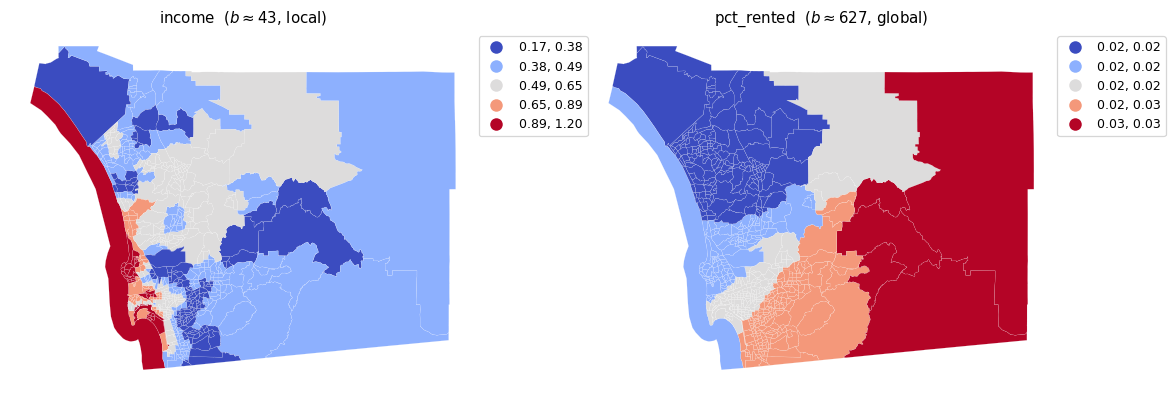

In [18]:
gdf["mgwr_income"] = mgwr.params[:, 1]
gdf["mgwr_rented"] = mgwr.params[:, 2]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
gdf.plot(column="mgwr_income", cmap="coolwarm", scheme="FisherJenks", k=5,
         legend=True, legend_kwds={"bbox_to_anchor": (1.25, 1.0)},
         linewidth=0.1, edgecolor="white", ax=axes[0])
axes[0].set_title(r"income  ($b\approx43$, local)")

gdf.plot(column="mgwr_rented", cmap="coolwarm", scheme="FisherJenks", k=5,
         legend=True, legend_kwds={"bbox_to_anchor": (1.25, 1.0)},
         linewidth=0.1, edgecolor="white", ax=axes[1])
axes[1].set_title(r"pct_rented  ($b\approx627$, global)")

for a in axes:
    a.axis("off")
plt.tight_layout()
plt.show()

In [19]:
print("MGWR income beta:      %.2f .. %.2f" %
      (gdf['mgwr_income'].min(), gdf['mgwr_income'].max()))
print("MGWR pct_rented beta:  %.2f .. %.2f" %
      (gdf['mgwr_rented'].min(), gdf['mgwr_rented'].max()))

MGWR income beta:      0.17 .. 1.20
MGWR pct_rented beta:  0.02 .. 0.03


The income slope still swings across space (~0.17–1.20) while `pct_rented` is nearly constant (~0.02–0.03) — its large bandwidth has flattened it into a single global effect, exactly as MGWR intended.

## When to use GWR vs MGWR

- **GWR** — exploratory analysis, or when all predictors plausibly act at a similar scale; one bandwidth, cheaper to fit.
- **MGWR** — when different processes operate at different scales (theory or a noisy/smooth split in GWR surfaces suggests it); reports a bandwidth per predictor and, here, a lower AICc.

**Lesson —** match the model to the process: use GWR to *discover* spatial variation, MGWR to *resolve the scale* at which each predictor's effect actually operates.

## References

- Fotheringham, A. S., Brunsdon, C., & Charlton, M. (2002). *Geographically Weighted Regression: The Analysis of Spatially Varying Relationships.* Wiley.
- Fotheringham, A. S., Yang, W., & Kang, W. (2017). Multiscale geographically weighted regression (MGWR). *Annals of the AAG*, 107(6), 1247–1265.
- Oshan, T. M., Li, Z., Kang, W., Wolf, L. J., & Fotheringham, A. S. (2019). mgwr: A Python implementation of multiscale geographically weighted regression. *ISPRS IJGI*, 8(6), 269. https://github.com/pysal/mgwr
- Rey, S. J., Arribas-Bel, D., & Wolf, L. J. *Geographic Data Science with Python.* https://geographicdata.science/book/
- GDSL-UL — *Spatial Analysis and Modelling*, Ch. 9 (GWR). https://gdsl-ul.github.io/san/09-gwr.html